# Scikit Learn Week 4 - Joshua Lewi (2473018)

## 5. Simple Linear Regession

In [1]:
import pandas as pd

pizza = {'diameter': [6, 8, 10, 14, 18],
         'harga': [7, 9, 13, 17.5, 18]}

pizza_df = pd.DataFrame(pizza)
print(pizza_df)

   diameter  harga
0         6    7.0
1         8    9.0
2        10   13.0
3        14   17.5
4        18   18.0


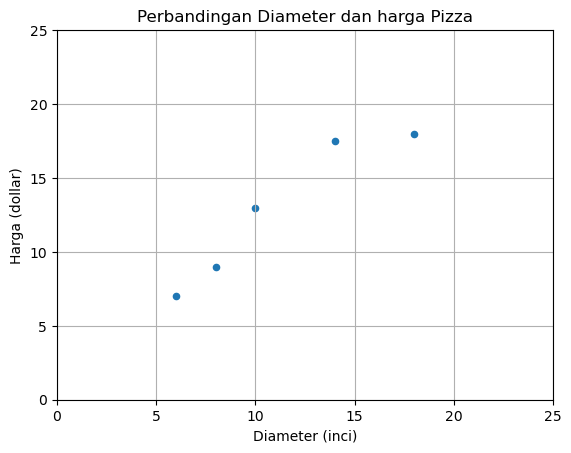

In [2]:
import matplotlib.pyplot as plt

pizza_df.plot(kind='scatter', x='diameter', y='harga')

plt.title('Perbandingan Diameter dan harga Pizza')
plt.xlabel('Diameter (inci)')
plt.ylabel('Harga (dollar)')
plt.xlim(0, 25)
plt.ylim(0, 25)
plt.grid(True)
plt.show()

#### Simple Linear Regression Model

In [3]:
import numpy as np

X = np.array(pizza_df['diameter'])
y = np.array(pizza_df['harga'])

print(f'X: {X}')
print(f'y: {y}')

X: [ 6  8 10 14 18]
y: [ 7.   9.  13.  17.5 18. ]


In [4]:
X = X.reshape(-1, 1)
X.shape

(5, 1)

In [5]:
X

array([[ 6],
       [ 8],
       [10],
       [14],
       [18]], dtype=int64)

#### Training Simple Linear Regression Model

In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

#### Visualisasi Simple Linear Regression Model

In [7]:
X_vis = np.array([0, 25]).reshape(-1, 1)
y_vis = model.predict(X_vis)

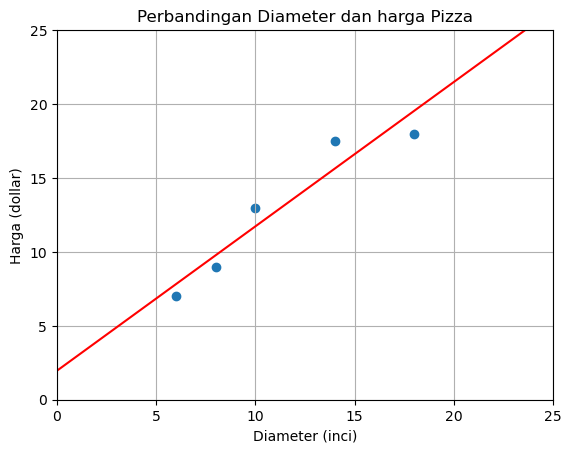

In [8]:
plt.scatter(X, y)
plt.plot(X_vis, y_vis, '-r')

plt.title('Perbandingan Diameter dan harga Pizza')
plt.xlabel('Diameter (inci)')
plt.ylabel('Harga (dollar)')
plt.xlim(0, 25)
plt.ylim(0, 25)
plt.grid(True)
plt.show()

In [10]:
#intercept adalah nilai y ketika x = 0
print(f'Intercept: {model.intercept_}')
#slope adalah nilai perubahan y ketika x berubah 1  (berpengaruh pada tingkat kemiringan garis linear)
print(f'Slope: {model.coef_}')

#rumus linear regression: y = beta * x + alpha
#beta = slope
#alpha = intercept

Intercept: 1.965517241379315
Slope: [0.9762931]


#### Mencari/kalkulasi nilai slope

In [11]:
#beta = covariance(X, y) / variance(X)
print(f'X:\n{X}\n')
print(f'X flatten: {X.flatten()}\n')
print(f'y:{y}')

X:
[[ 6]
 [ 8]
 [10]
 [14]
 [18]]

X flatten: [ 6  8 10 14 18]

y:[ 7.   9.  13.  17.5 18. ]


Variance

In [12]:
variance_x = np.var(X.flatten(), ddof=1)
print(f'Variance: {variance_x}')

Variance: 23.2


Covariance

In [13]:
np.cov(X.flatten(), y)

array([[23.2 , 22.65],
       [22.65, 24.3 ]])

In [16]:
covariance_xy = np.cov(X.flatten(), y)[0][1]

print(f'Covariance: {covariance_xy}')

Covariance: 22.65


Slope

In [17]:
slope = covariance_xy / variance_x
print(f'Slope: {slope}')

Slope: 0.9762931034482758


#### Mencari/kalkulasi nilai intercept

In [18]:
#alpha = mean(y) - beta * mean(X)
intercept = np.mean(y) - slope * np.mean(X)

print(f'Intercept: {intercept}')

Intercept: 1.9655172413793114


#### Prediksi harga pizza

In [19]:
diameter_pizza = np.array([12, 20, 23]).reshape(-1, 1)
diameter_pizza

array([[12],
       [20],
       [23]])

In [20]:
prediksi_harga = model.predict(diameter_pizza)
prediksi_harga

array([13.68103448, 21.49137931, 24.42025862])

In [21]:
for dmtr, hrg in zip(diameter_pizza, prediksi_harga):
    print(f'Prediksi harga pizza dengan diameter {dmtr} inci adalah ${hrg:.2f}')

Prediksi harga pizza dengan diameter [12] inci adalah $13.68
Prediksi harga pizza dengan diameter [20] inci adalah $21.49
Prediksi harga pizza dengan diameter [23] inci adalah $24.42


#### Evaluasi Simple Linear Regression Model

Training & Testing Dataset

In [22]:
X_train = np.array([6, 8, 10, 14, 18]).reshape(-1, 1)
y_train = np.array([7, 9, 13, 17.5, 18])

X_test = np.array([8, 9, 11, 16, 12]).reshape(-1, 1)
y_test = np.array([11, 8.5, 15, 18, 11])

Training Simple Linear Regression Model

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Evaluasi Linear Regression Model dengan Coefficient of Determination atau R-squared (cek wikipedia)

In [24]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r_squared = r2_score(y_test, y_pred)
print(f'R-squared: {r_squared}')

R-squared: 0.6620052929422553


#### Mencari nilai R-squared

In [25]:
#R-squared = 1 - (SS_res / SS_tot)
#SS_res (subsquare residual) = sum((y_test - y_pred) ** 2)
#SS_res adalah proses perhitungan selisih antara nilai aktual (y_test) dan nilai prediksi (y_pred), kemudian dikuadratkan untuk menghilangkan tanda negatif dan memberikan bobot lebih pada kesalahan yang lebih besar. Semakin kecil nilai SS_res, semakin baik model dalam memprediksi data.
#SS_tot (subsquare total) = sum((y_test - np.mean(y_test)) ** 2)
#SS_tot adalah proses perhitungan selisih antara nilai aktual (y_test) dan rata-rata nilai aktual (np.mean(y_test)), kemudian dikuadratkan untuk menghilangkan tanda negatif dan memberikan bobot lebih pada variasi yang lebih besar dalam data. Semakin besar nilai SS_tot, semakin banyak variasi dalam data yang harus dijelaskan oleh model. R-squared memberikan ukuran seberapa baik model menjelaskan variasi dalam data, dengan nilai 1 menunjukkan model yang sempurna dan nilai 0 menunjukkan model yang tidak menjelaskan variasi sama sekali.

In [26]:
ss_res = sum([(y_i - model.predict(x_i.reshape(-1, 1))[0])**2 for x_i, y_i in zip(X_test, y_test)])

print(f'SS_res: {ss_res}')

SS_res: 19.1980993608799


In [27]:
mean_y = np.mean(y_test)
ss_tot = sum([(y_i - mean_y)**2 for y_i in y_test])
print(f'SS_tot: {ss_tot}')

SS_tot: 56.8


In [28]:
r_squared = 1 - (ss_res / ss_tot)
print(f'R-squared (manual calculation): {r_squared}')

R-squared (manual calculation): 0.6620052929422553
